CELL 1 — Install the required packages

In [1]:
%pip install pandas requests sqlalchemy psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


# 0. DATA SOURCE / INPUT–OUTPUT MANIFEST

This section documents exactly where the BASt input comes from, where it is stored locally, and how it enters the PostgreSQL pipeline.

### BASt bridge statistics
- **External source:** BASt bridge statistics dataset (Brückenstatistik), supplied as CSV.
- **Acquisition:** The BASt CSV is obtained/downloaded separately and kept as a local raw input. This notebook does **not** assume that the BASt table already exists in PostgreSQL.
- **Local raw storage:** `Dataset_PlanA-B/BASt/`
- **Expected file:** `Brueckenstatistik_BASt_raw.csv`
- **Canonical local input:** `BAST_CSV_FILE` defined below.
- **Processing:** CSV → pandas DataFrame → PostgreSQL raw table `raw_bridge_statistics.brueckenstatistik_bast_raw`.
- **Downstream:** The BASt raw SQL table is used by this notebook for the bridge/GIS join and creation of `raw_bridge_statistics.bridge_master`.

### GIS source
- **External source:** ArcGIS Feature Service (Brückenstatistik Deutschland).
- **Acquisition:** Queried directly through the ArcGIS REST endpoint in batches.
- **Local raw GIS file:** Not required for the current workflow; the downloaded GIS records are held in memory and written to PostgreSQL.
- **PostgreSQL output:** `raw_bridge_statistics.brueckenstatistik_gis`.

### Transfer chain
`BASt CSV → pandas → raw_bridge_statistics.brueckenstatistik_bast_raw → BASt/GIS join → raw_bridge_statistics.bridge_master`

> **Portability rule:** No user-specific Windows path is embedded in the processing logic except through `PROJECT_ROOT`. On another computer, set `BRIDGE_PROJECT_ROOT` or place the project folder so that `Dataset_PlanA-B/BASt/` exists.

# 1. Project configuration

Central configuration for local project paths, PostgreSQL tables, and the ArcGIS source.

In [2]:
from pathlib import Path
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
from getpass import getpass
from sqlalchemy import create_engine, text

# ------------------------------------------------------------
# Portable project root
# ------------------------------------------------------------
def find_project_root():
    env_root = os.getenv('BRIDGE_PROJECT_ROOT')
    if env_root:
        root = Path(env_root).expanduser().resolve()
        if (root / 'Dataset_PlanA-B').exists():
            return root
        raise FileNotFoundError(f'BRIDGE_PROJECT_ROOT does not contain Dataset_PlanA-B: {root}')
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / 'Dataset_PlanA-B').exists():
            return candidate
    raise FileNotFoundError('Project root not found. Set BRIDGE_PROJECT_ROOT to the folder containing Dataset_PlanA-B.')

PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / 'Dataset_PlanA-B'
BAST_DIR = DATASET_ROOT / 'BASt'
BAST_CSV_FILE = BAST_DIR / 'Brueckenstatistik_BASt_raw.csv'

# PostgreSQL
PG_HOST = 'localhost'
PG_PORT = 5432
PG_DATABASE = 'Final_Project'
PG_USER = 'postgres'

# PostgreSQL schema / tables
PG_SCHEMA = 'raw_bridge_statistics'
BAST_TABLE = 'brueckenstatistik_bast_raw'
GIS_TABLE = 'brueckenstatistik_gis'
MASTER_TABLE = 'bridge_master'

# Mandatory bridge inclusion rule
MIN_BUILD_YEAR = 1900

# ArcGIS Feature Service
ARCGIS_QUERY_URL = (
    'https://services2.arcgis.com/'
    'jUpNdisbWqRpMo35/ArcGIS/rest/services/'
    'Br%C3%BCckenstatistik_Deutschland/FeatureServer/0/query'
)
BATCH_SIZE = 2000

GIS_FIELDS = [
    'bwnr', 'tbwnr', 'id_nr', 'station_m',
    'zugeordneter_sachverhalt', 'ort', 'kreis', 'bl', 'X', 'Y'
]

print('Project root:', PROJECT_ROOT)
print('BASt CSV:', BAST_CSV_FILE)
print('BASt CSV exists:', BAST_CSV_FILE.exists())

Project root: C:\Datenanalyse\final Project
BASt CSV: C:\Datenanalyse\final Project\Dataset_PlanA-B\BASt\Brueckenstatistik_BASt_raw.csv
BASt CSV exists: True


CELL 4 — Connect Python to PostgreSQL

In [3]:
# ============================================================
# POSTGRESQL CONNECTION
# ============================================================

PG_PASSWORD = getpass("Enter PostgreSQL password: ")

engine = create_engine(
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}"
    f"@{PG_HOST}:{PG_PORT}/{PG_DATABASE}"
)

with engine.connect() as conn:
    current_database = conn.execute(
        text("SELECT current_database();")
    ).scalar()

print("Connected successfully.")
print("Database:", current_database)

Connected successfully.
Database: Final_Project


CELL 5 — Read the BASt table from PostgreSQL

In [4]:
# ============================================================
# LOAD BASt CSV → PostgreSQL RAW TABLE → YEAR FILTER
# ============================================================

if not BAST_CSV_FILE.exists():
    raise FileNotFoundError(f'BASt CSV not found: {BAST_CSV_FILE}')

bast_raw_df = pd.read_csv(BAST_CSV_FILE, low_memory=False)
print('BASt CSV loaded:', BAST_CSV_FILE)
print('Raw BASt records:', f'{len(bast_raw_df):,}')
print('Raw BASt columns:', len(bast_raw_df.columns))

# Store the unfiltered BASt input in PostgreSQL as the canonical raw SQL layer.
bast_raw_df.to_sql(
    name=BAST_TABLE, con=engine, schema=PG_SCHEMA,
    if_exists='replace', index=False, method='multi', chunksize=5000
)
print(f'Raw BASt table written: {PG_SCHEMA}.{BAST_TABLE}')

bast_df = bast_raw_df.copy()
bast_df['id_nr'] = bast_df['id_nr'].astype('string').str.strip()
bast_df['baujahr'] = pd.to_numeric(bast_df['baujahr'], errors='coerce')

before_filter = len(bast_df)
invalid_year = int(bast_df['baujahr'].isna().sum())
bast_df = bast_df.loc[bast_df['baujahr'] > MIN_BUILD_YEAR].copy()

print('BASt records before filter:', before_filter)
print('Invalid/missing Baujahr:', invalid_year)
print(f'Eligible bridges (Baujahr > {MIN_BUILD_YEAR}):', len(bast_df))


BASt CSV loaded: C:\Datenanalyse\final Project\Dataset_PlanA-B\BASt\Brueckenstatistik_BASt_raw.csv
Raw BASt records: 52,625
Raw BASt columns: 17
Raw BASt table written: raw_bridge_statistics.brueckenstatistik_bast_raw
BASt records before filter: 52625
Invalid/missing Baujahr: 0
Eligible bridges (Baujahr > 1900): 52214


CELL 6 — Get the total number of ArcGIS records

In [5]:
# ============================================================
# ARCGIS RECORD COUNT
# ============================================================

count_params = {
    "where": "1=1",
    "returnCountOnly": "true",
    "f": "json"
}

response = requests.get(
    ARCGIS_QUERY_URL,
    params=count_params,
    timeout=60
)

response.raise_for_status()

count_data = response.json()

if "error" in count_data:
    raise RuntimeError(count_data["error"])

gis_expected_count = count_data["count"]

print("ArcGIS records reported by service:", gis_expected_count)

ArcGIS records reported by service: 52553


CELL 7 — Download all GIS records in batches of 2,000

In [6]:
# ============================================================
# DOWNLOAD ALL GIS FEATURES
# ============================================================

all_records = []
offset = 0

session = requests.Session()

while True:

    params = {
        "where": "1=1",
        "outFields": ",".join(GIS_FIELDS),
        "returnGeometry": "true",
        "resultOffset": offset,
        "resultRecordCount": BATCH_SIZE,
        "orderByFields": "OBJECTID ASC",
        "f": "json"
    }

    response = session.get(
        ARCGIS_QUERY_URL,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    data = response.json()

    if "error" in data:
        raise RuntimeError(data["error"])

    features = data.get("features", [])

    if not features:
        break

    for feature in features:

        record = feature.get("attributes", {}).copy()

        geometry = feature.get("geometry")

        if geometry is not None:
            record["geom_x"] = geometry.get("x")
            record["geom_y"] = geometry.get("y")
        else:
            record["geom_x"] = None
            record["geom_y"] = None

        all_records.append(record)

    start = offset + 1
    end = offset + len(features)

    print(
        f"Downloaded: {start:,} - {end:,} "
        f"| Total: {len(all_records):,}"
    )

    if len(features) < BATCH_SIZE:
        break

    offset += BATCH_SIZE


gis_df = pd.DataFrame(all_records)

print("\nGIS download completed.")
print("GIS records:", len(gis_df))

Downloaded: 1 - 2,000 | Total: 2,000
Downloaded: 2,001 - 4,000 | Total: 4,000
Downloaded: 4,001 - 6,000 | Total: 6,000
Downloaded: 6,001 - 8,000 | Total: 8,000
Downloaded: 8,001 - 10,000 | Total: 10,000
Downloaded: 10,001 - 12,000 | Total: 12,000
Downloaded: 12,001 - 14,000 | Total: 14,000
Downloaded: 14,001 - 16,000 | Total: 16,000
Downloaded: 16,001 - 18,000 | Total: 18,000
Downloaded: 18,001 - 20,000 | Total: 20,000
Downloaded: 20,001 - 22,000 | Total: 22,000
Downloaded: 22,001 - 24,000 | Total: 24,000
Downloaded: 24,001 - 26,000 | Total: 26,000
Downloaded: 26,001 - 28,000 | Total: 28,000
Downloaded: 28,001 - 30,000 | Total: 30,000
Downloaded: 30,001 - 32,000 | Total: 32,000
Downloaded: 32,001 - 34,000 | Total: 34,000
Downloaded: 34,001 - 36,000 | Total: 36,000
Downloaded: 36,001 - 38,000 | Total: 38,000
Downloaded: 38,001 - 40,000 | Total: 40,000
Downloaded: 40,001 - 42,000 | Total: 42,000
Downloaded: 42,001 - 44,000 | Total: 44,000
Downloaded: 44,001 - 46,000 | Total: 46,000
Downl

CELL 8 — Prepare the GIS Data

In [7]:
# ============================================================
# PREPARE GIS DATA
# ============================================================

gis_df["id_nr"] = (
    gis_df["id_nr"]
    .astype("string")
    .str.strip()
)

gis_df["tbwnr"] = (
    gis_df["tbwnr"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

print("GIS records:", len(gis_df))
print("GIS unique id_nr:", gis_df["id_nr"].nunique())

GIS records: 52553
GIS unique id_nr: 52553


CELL 9 — Final validation

In [8]:
# FINAL VALIDATION

assert (bast_df["baujahr"] > 1900).all()
assert bast_df["id_nr"].is_unique
assert gis_df["id_nr"].is_unique

matched = bast_df["id_nr"].isin(gis_df["id_nr"])
matched_count = int(matched.sum())
missing_count = int((~matched).sum())

print("Eligible BASt bridges (Baujahr > 1900):", f"{len(bast_df):,}")
print("Matched GIS records:", f"{matched_count:,}")
print("Without GIS:", f"{missing_count:,}")
print("Match rate:", f"{matched_count / len(bast_df) * 100:.2f}%")
print("Year range:", int(bast_df["baujahr"].min()), "-", int(bast_df["baujahr"].max()))


Eligible BASt bridges (Baujahr > 1900): 52,214
Matched GIS records: 51,982
Without GIS: 232
Match rate: 99.56%
Year range: 1901 - 3019


CELL 10 — Save GIS Data into PostgreSQL

In [9]:
# ============================================================
# WRITE GIS DATA TO POSTGRESQL
# ============================================================

gis_df.to_sql(
    name=GIS_TABLE,
    con=engine,
    schema=PG_SCHEMA,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=5000
)

print(
    f'GIS table created successfully: '
    f'"{PG_SCHEMA}"."{GIS_TABLE}"'
)

GIS table created successfully: "raw_bridge_statistics"."brueckenstatistik_gis"


CELL 11 — Add an index on id_nr

In [10]:
# ============================================================
# INDEX GIS JOIN KEY
# ============================================================

with engine.begin() as conn:
    conn.execute(
        text(
            f'''
            CREATE INDEX IF NOT EXISTS
            idx_{GIS_TABLE}_id_nr
            ON "{PG_SCHEMA}"."{GIS_TABLE}" (id_nr);
            '''
        )
    )

print("GIS id_nr index created.")

GIS id_nr index created.


CELL 12 — Create the Master Bridge Table

In [11]:
# CREATE MASTER BRIDGE TABLE
# Defense-in-depth: master table contains ONLY Baujahr > 1900.

master_sql = f'''
DROP TABLE IF EXISTS "{PG_SCHEMA}"."{MASTER_TABLE}";

CREATE TABLE "{PG_SCHEMA}"."{MASTER_TABLE}" AS
SELECT
    b.*,
    g.station_m AS gis_station_m,
    g.zugeordneter_sachverhalt AS gis_road_context,
    g.ort AS gis_ort,
    g.kreis AS gis_kreis,
    g.bl AS gis_bundesland,
    g."X" AS gis_x_attribute,
    g."Y" AS gis_y_attribute,
    g.geom_x,
    g.geom_y
FROM "{PG_SCHEMA}"."{BAST_TABLE}" AS b
LEFT JOIN "{PG_SCHEMA}"."{GIS_TABLE}" AS g
    ON b.id_nr = g.id_nr
WHERE b.baujahr > 1900;
'''

with engine.begin() as conn:
    conn.execute(text(master_sql))

print(f'Master table created: "{PG_SCHEMA}"."{MASTER_TABLE}"')


Master table created: "raw_bridge_statistics"."bridge_master"


CELL 13 — Verify the Master Table

In [12]:
# VERIFY MASTER TABLE

with engine.connect() as conn:
    master_count = conn.execute(
        text(f'''
            SELECT COUNT(*)
            FROM "{PG_SCHEMA}"."{MASTER_TABLE}";
        ''')
    ).scalar()

    invalid_year_count = conn.execute(
        text(f'''
            SELECT COUNT(*)
            FROM "{PG_SCHEMA}"."{MASTER_TABLE}"
            WHERE baujahr <= 1900 OR baujahr IS NULL;
        ''')
    ).scalar()

    gis_location_count = conn.execute(
        text(f'''
            SELECT COUNT(*)
            FROM "{PG_SCHEMA}"."{MASTER_TABLE}"
            WHERE geom_x IS NOT NULL AND geom_y IS NOT NULL;
        ''')
    ).scalar()

print("Total eligible records:", f"{master_count:,}")
print("Invalid Baujahr (must be 0):", f"{invalid_year_count:,}")
print("Records with GIS point:", f"{gis_location_count:,}")

assert invalid_year_count == 0


Total eligible records: 52,214
Invalid Baujahr (must be 0): 0
Records with GIS point: 51,428


CELL 14 — Preview the final table

In [13]:
# PREVIEW FINAL DATASET

master_preview = pd.read_sql(
    f'''
    SELECT
        id_nr, bwnr, tbwnr, baujahr, bauwerk, bauwerksart_text,
        laenge, breite, flaeche, zustandsnote,
        gis_station_m, gis_road_context, gis_ort, gis_kreis,
        gis_bundesland, gis_x_attribute, gis_y_attribute,
        geom_x, geom_y
    FROM "{PG_SCHEMA}"."{MASTER_TABLE}"
    WHERE baujahr > 1900
    ORDER BY baujahr, id_nr
    LIMIT 10;
    ''',
    engine
)

master_preview


,id_nr,bwnr,tbwnr,baujahr,bauwerk,bauwerksart_text,laenge,breite,flaeche,zustandsnote,gis_station_m,gis_road_context,gis_ort,gis_kreis,gis_bundesland,gis_x_attribute,gis_y_attribute,geom_x,geom_y
0,5525855._0,5525855,0,1901,Brücke ...,Gewölbe-/Bogenbrücke ohne Aufbeton ...,3.50,7.10,25,1.9,60.0,B 278,Bischofsheim ...,Landkreis Rhön-Grabfeld ...,BY,569679.1,5586963.0,1.111086e+06,6.521176e+06
1,5442501._1,5442501,1,1902,Brücke ...,Gewölbe-/Bogenbrücke mit Aufbeton ohne Verbund...,25.30,6.10,154,2.8,239.0,B 101,"Aue-Bad Schlema, OT Aue ...",Erzgebirgskreis ...,SN,761897.9,5610415.0,1.413768e+06,6.548527e+06
2,5442502._0,5442502,0,1902,Brücke ...,Gewölbe-/Bogenbrücke mit Lastverteilungsplatte...,51.40,11.00,565,2.8,246.0,B 101,"Aue-Bad Schlema, OT Aue ...",Erzgebirgskreis ...,SN,762050.5,5610621.0,1.414023e+06,6.548838e+06
3,6410540._0,6410540,0,1902,Brücke ...,"Plattenbalkenbrücke, Trägerrostbrücke ...",19.50,7.10,138,3.0,488.0,B 423,Altenglan ...,KUSEL ...,RP,388758.8,5489033.0,8.306975e+05,6.367620e+06
4,4912775._0,4912775,0,1903,Brücke ...,"Plattenbalkenbrücke, Trägerrostbrücke ...",5.29,2.35,21,2.0,200.0,B 54,Olpe-Rosenthal ...,Olpe ...,NW,417673.7,5654099.0,8.711768e+05,6.627051e+06
5,4912776._0,4912776,0,1903,Brücke ...,Gewölbe- bzw. Bogenbrücke ...,4.50,4.10,21,1.5,NaN,B 55,Olpe-Rosenthal ...,Olpe ...,NaN,NaN,NaN,NaN,NaN
6,4912790._0,4912790,0,1903,Brücke ...,Gewölbe- bzw. Bogenbrücke ...,2.50,26.25,65,2.4,230.0,B 55,Drolshagen-Eichenermühle ...,Olpe ...,NW,416838.1,5652974.0,8.698792e+05,6.625240e+06
7,5309829._0,5309829,0,1903,Brücke ...,Gewölbe- bzw. Bogenbrücke ...,3.35,13.80,46,2.0,1547.0,B 9,Rolandseck ...,AHRWEILER ...,RP,373159.7,5610913.0,8.022023e+05,6.557203e+06
8,5809601._0,5809601,0,1903,Brücke ...,Gewölbe- bzw. Bogenbrücke ...,3.40,13.00,44,2.9,7653.0,B 49,Ellenz ...,COCHEM-ZELL ...,RP,373238.4,5553652.0,8.044746e+05,6.467354e+06
9,5809603._0,5809603,0,1903,Brücke ...,Gewölbe- bzw. Bogenbrücke ...,5.00,10.50,53,2.2,505.0,B 49,Cochem ...,COCHEM-ZELL ...,RP,369383.4,5555729.0,7.983954e+05,6.470452e+06


## CELL 15 — Visualisierung

Alle Grafiken beziehen sich ausschließlich auf Brücken mit `Baujahr > 1900`.


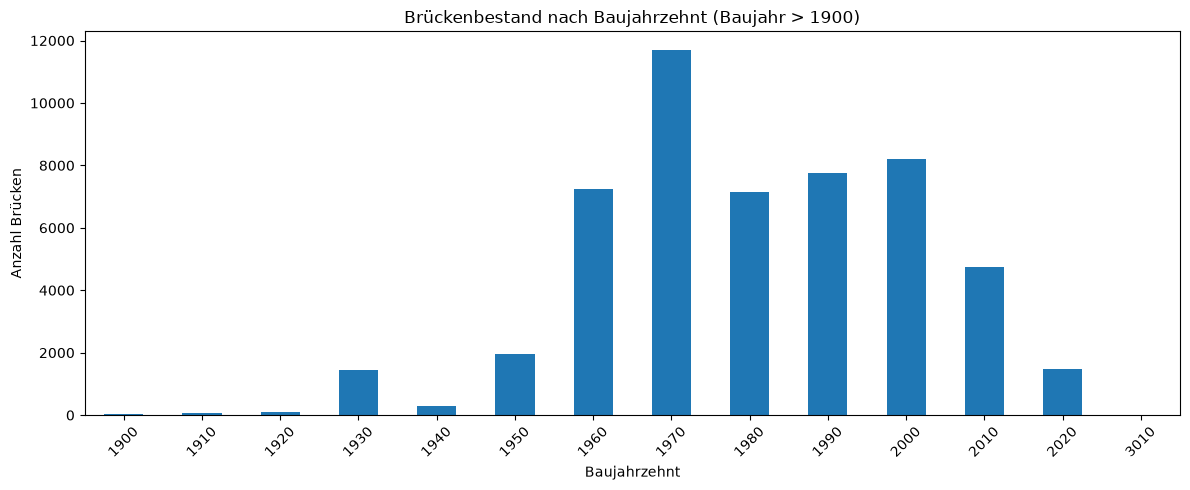

In [14]:
# VISUALISIERUNG: BRÜCKEN NACH BAUJAHRZEHNT

import matplotlib.pyplot as plt

analysis_df = pd.read_sql(
    f'''
    SELECT baujahr
    FROM "{PG_SCHEMA}"."{MASTER_TABLE}"
    WHERE baujahr > 1900
    ''',
    engine
)

analysis_df["baujahr"] = pd.to_numeric(analysis_df["baujahr"], errors="coerce")
analysis_df["dekade"] = (analysis_df["baujahr"] // 10 * 10).astype("Int64")
counts = analysis_df["dekade"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
counts.plot(kind="bar")
plt.title("Brückenbestand nach Baujahrzehnt (Baujahr > 1900)")
plt.xlabel("Baujahrzehnt")
plt.ylabel("Anzahl Brücken")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


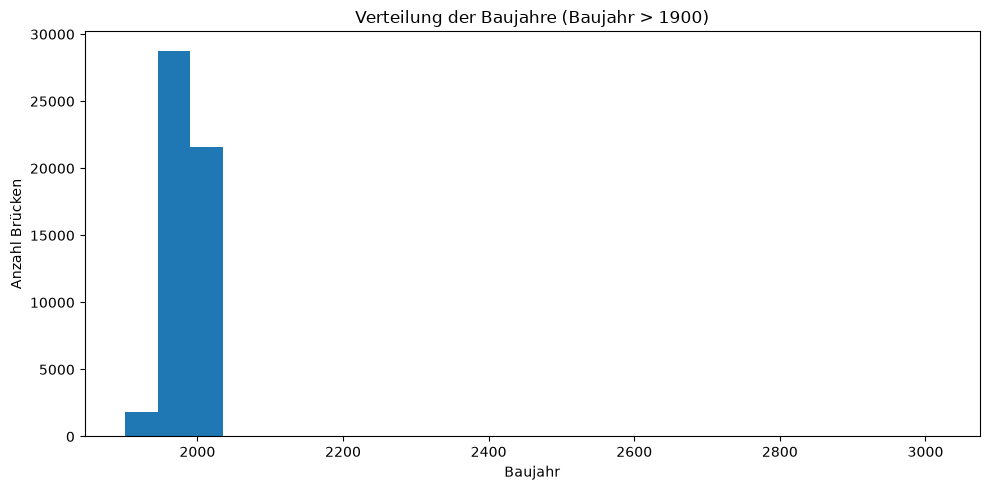

In [15]:
# VISUALISIERUNG: VERTEILUNG DER BAUJAHRE

plt.figure(figsize=(10, 5))
plt.hist(analysis_df["baujahr"].dropna(), bins=25)
plt.title("Verteilung der Baujahre (Baujahr > 1900)")
plt.xlabel("Baujahr")
plt.ylabel("Anzahl Brücken")
plt.tight_layout()
plt.show()


## CELL 18 — Ergebnis / Final Report

Zusammenfassung der geprüften Brückenbasis. **Keine Prognose / kein Prediction-Modell.**


In [16]:
# FINAL RESULTS / BRIEF

with engine.connect() as conn:
    result = conn.execute(
        text(f'''
            SELECT
                COUNT(*) AS n_bridges,
                MIN(baujahr) AS min_baujahr,
                MAX(baujahr) AS max_baujahr,
                ROUND(AVG(baujahr)::numeric, 1) AS mean_baujahr,
                ROUND(AVG(zustandsnote)::numeric, 2) AS mean_zustandsnote,
                ROUND(AVG(laenge)::numeric, 2) AS mean_laenge,
                ROUND(AVG(breite)::numeric, 2) AS mean_breite,
                ROUND(AVG(flaeche)::numeric, 2) AS mean_flaeche,
                COUNT(*) FILTER (
                    WHERE geom_x IS NOT NULL AND geom_y IS NOT NULL
                ) AS n_with_gis
            FROM "{PG_SCHEMA}"."{MASTER_TABLE}"
            WHERE baujahr > 1900;
        ''')
    ).mappings().one()

results_df = pd.DataFrame([dict(result)])

print("========================================")
print("FINAL RESULT / BRIEF")
print("========================================")
print(f"Bridges: {int(result['n_bridges']):,}")
print(f"Baujahr range: {int(result['min_baujahr'])}–{int(result['max_baujahr'])}")
print(f"Mean Baujahr: {result['mean_baujahr']}")
print(f"Mean Zustandsnote: {result['mean_zustandsnote']}")
print(f"Mean Länge [m]: {result['mean_laenge']}")
print(f"Mean Breite [m]: {result['mean_breite']}")
print(f"Mean Fläche [m²]: {result['mean_flaeche']}")
print(f"GIS coverage: {int(result['n_with_gis']) / int(result['n_bridges']) * 100:.2f}%")

results_df


FINAL RESULT / BRIEF
Bridges: 52,214
Baujahr range: 1901–3019
Mean Baujahr: 1985.1
Mean Zustandsnote: 2.21
Mean Länge [m]: 41.97
Mean Breite [m]: 16.62
Mean Fläche [m²]: 607.97
GIS coverage: 98.49%


,n_bridges,min_baujahr,max_baujahr,mean_baujahr,mean_zustandsnote,mean_laenge,mean_breite,mean_flaeche,n_with_gis
0,52214,1901,3019,1985.1,2.21,41.97,16.62,607.97,51428


In [17]:
# FINAL HARD CHECK

with engine.connect() as conn:
    invalid_final = conn.execute(
        text(f'''
            SELECT COUNT(*)
            FROM "{PG_SCHEMA}"."{MASTER_TABLE}"
            WHERE baujahr <= 1900 OR baujahr IS NULL;
        ''')
    ).scalar()

print("Final check — Baujahr <= 1900 or missing:", invalid_final)
assert invalid_final == 0

print("OK: Nur Brücken mit Baujahr > 1900 befinden sich in der finalen Master-Liste.")


Final check — Baujahr <= 1900 or missing: 0
OK: Nur Brücken mit Baujahr > 1900 befinden sich in der finalen Master-Liste.
